In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.stats import randint
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Recommender-system-related implementations
from src.models import (
    ItemMeanRecommender,                # baseline
    UserKNNBasicRecommender,            # main model
)
from src.data_splits import load_premade_splits
from src.evaluator import RecommenderEvaluator
from src.scorer import RecommenderScorer
from src.debug import low_coverage_check

# 1. Data

In [2]:
df = pd.read_csv(
    'data/u.data', 
    sep='\t', 
    encoding='utf-8', 
    header=None, 
    names=['user_id', 'item_id', 'rating', 'timestamp']
)
df.sort_values('timestamp', ascending=True, inplace=True)
df.head()

,user_id,item_id,rating,timestamp
214,259,255,4,874724710
83965,259,286,4,874724727
43027,259,298,4,874724754
21396,259,185,4,874724781
82655,259,173,4,874724843


# 2. Hyperparam tuning

In [3]:
param_dist_basic = {
    'n_neighbors': randint(5, 60),
    'min_support': randint(2, 15),
    'center_ratings': [True]
}
param_dist_basic_no_centering = {
    'n_neighbors': randint(5, 60),
    'min_support': randint(2, 15),
    'center_ratings': [False]
}

# Use the first fold for tuning to save time
train_df_tuning, test_df_tuning = next(load_premade_splits("data"))

# Prepare combined data and PredefinedSplit
train_size = len(train_df_tuning)
test_size = len(test_df_tuning)
combined_df = pd.concat([train_df_tuning, test_df_tuning], ignore_index=True)
split_index = [-1]*train_size + [0]*test_size
ps = PredefinedSplit(split_index)

scorer = RecommenderScorer()

print("Tuning UserKNNBasic...")
rs_basic = RandomizedSearchCV(UserKNNBasicRecommender(), param_distributions=param_dist_basic, n_iter=25, scoring=scorer, cv=ps, random_state=42, refit=False, n_jobs=1)
rs_basic.fit(combined_df, None)
best_params_basic = rs_basic.best_params_
print(f"Basic Best params: {best_params_basic} | Best score: {rs_basic.best_score_}")

print("Tuning UserKNNBasic (w/o centering ratings)...")
rs_basic_no_centering = RandomizedSearchCV(UserKNNBasicRecommender(), param_distributions=param_dist_basic_no_centering, n_iter=25, scoring=scorer, cv=ps, random_state=42, refit=False, n_jobs=1)
rs_basic_no_centering.fit(combined_df, None)
best_params_basic_no_centering = rs_basic_no_centering.best_params_
print(f"Basic Best params: {best_params_basic_no_centering} | Best score: {rs_basic_no_centering.best_score_}")

Tuning UserKNNBasic...
Basic Best params: {'center_ratings': True, 'min_support': 14, 'n_neighbors': 48} | Best score: 0.27105263157894743
Tuning UserKNNBasic (w/o centering ratings)...
Basic Best params: {'center_ratings': False, 'min_support': 13, 'n_neighbors': 25} | Best score: 0.29627192982456146


In [4]:
# Collect all fold results
cv_fold_results = []

for fold, (train_df, test_df) in enumerate(load_premade_splits("data"), start=1):

    # =================== training ===================
    item_mean_baseline = ItemMeanRecommender()
    item_mean_baseline.fit(train_df)

    model_knn = UserKNNBasicRecommender(**best_params_basic)
    model_knn.fit(train_df)

    knn_no_centering = UserKNNBasicRecommender(**best_params_basic_no_centering)
    knn_no_centering.fit(train_df)

    # ================== evaluation ==================
    eval_report = {}
    for model in [item_mean_baseline, model_knn, knn_no_centering]:
        evaluator = RecommenderEvaluator(model, test_df, relevance_threshold=4, prec_rec_k=10)
        eval_results = evaluator.evaluation_report()
        if model != knn_no_centering:
            eval_report[model.__name__[:-11]] = eval_results
        else:
            eval_report[model.__name__[:-11] + " (no centering)"] = eval_results
    
    fold_df = pd.DataFrame(eval_report)
    print(fold_df)
    cv_fold_results.append(eval_report)

# ================= CROSS-VALIDATION SUMMARY =================
print("\n" + "="*75)
print("CROSS-VALIDATION SUMMARY (Mean ± Std Dev)")
print("="*75)

# Organize results by model and metric
models = list(cv_fold_results[0].keys())
metrics = list(cv_fold_results[0][models[0]].keys())

cv_summary = {}
for model_name in models:
    cv_summary[model_name] = {}
    for metric in metrics:
        scores = [fold_results[model_name][metric] for fold_results in cv_fold_results]
        mean_score = np.mean(scores)
        std_score = np.std(scores)
        cv_summary[model_name][metric] = f"{mean_score:.4f} ± {std_score:.4f}"

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
summary_df = pd.DataFrame(cv_summary)
print(summary_df)

                         ItemMean  UserKNNBasic  UserKNNBasic (no centering)
precision@10             0.215132      0.271053                     0.296272
recall@10                0.094623      0.172730                     0.179820
f1@10                    0.131436      0.210999                     0.223804
mean_absolute_error      0.827568      0.773843                     0.783775
root_mean_squared_error  1.033411      0.991158                     1.003099
coverage                 1.000000      0.998400                     0.998400
                         ItemMean  UserKNNBasic  UserKNNBasic (no centering)
precision@10             0.168478      0.217702                     0.237888
recall@10                0.097673      0.183214                     0.190328
f1@10                    0.123657      0.198975                     0.211467
mean_absolute_error      0.820695      0.760460                     0.772382
root_mean_squared_error  1.030484      0.978274                     0.992976

In [5]:
print("\n" + "="*75)
print("CROSS-VALIDATION SUMMARY (Mean ± Std Dev)")
print("="*75)

# Organize results by model and metric
models = list(cv_fold_results[0].keys())
metrics = list(cv_fold_results[0][models[0]].keys())

cv_summary = {}
for model_name in models:
    cv_summary[model_name] = {}
    for metric in metrics:
        scores = [fold_results[model_name][metric] for fold_results in cv_fold_results]
        mean_score = np.mean(scores)
        std_score = np.std(scores)
        cv_summary[model_name][metric] = f"{mean_score:.4f} ± {std_score:.4f}"

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
summary_df = pd.DataFrame(cv_summary)
print(summary_df)


CROSS-VALIDATION SUMMARY (Mean ± Std Dev)
                                ItemMean     UserKNNBasic UserKNNBasic (no centering)
precision@10             0.1544 ± 0.0340  0.2055 ± 0.0362             0.2184 ± 0.0440
recall@10                0.1045 ± 0.0075  0.1925 ± 0.0128             0.1875 ± 0.0059
f1@10                    0.1224 ± 0.0051  0.1961 ± 0.0088             0.1995 ± 0.0156
mean_absolute_error      0.8174 ± 0.0061  0.7633 ± 0.0062             0.7738 ± 0.0056
root_mean_squared_error  1.0246 ± 0.0063  0.9799 ± 0.0064             0.9921 ± 0.0064
coverage                 1.0000 ± 0.0000  0.9983 ± 0.0002             0.9983 ± 0.0002


Testing min_support = 0...
Testing min_support = 2...
Testing min_support = 4...
Testing min_support = 6...
Testing min_support = 8...
Testing min_support = 10...
Testing min_support = 12...
Testing min_support = 14...
Testing min_support = 16...
Testing min_support = 18...
Testing min_support = 20...
Testing n_neighbors = 5...
Testing n_neighbors = 10...
Testing n_neighbors = 15...
Testing n_neighbors = 20...
Testing n_neighbors = 25...
Testing n_neighbors = 30...
Testing n_neighbors = 35...
Testing n_neighbors = 40...
Testing n_neighbors = 45...
Testing n_neighbors = 50...


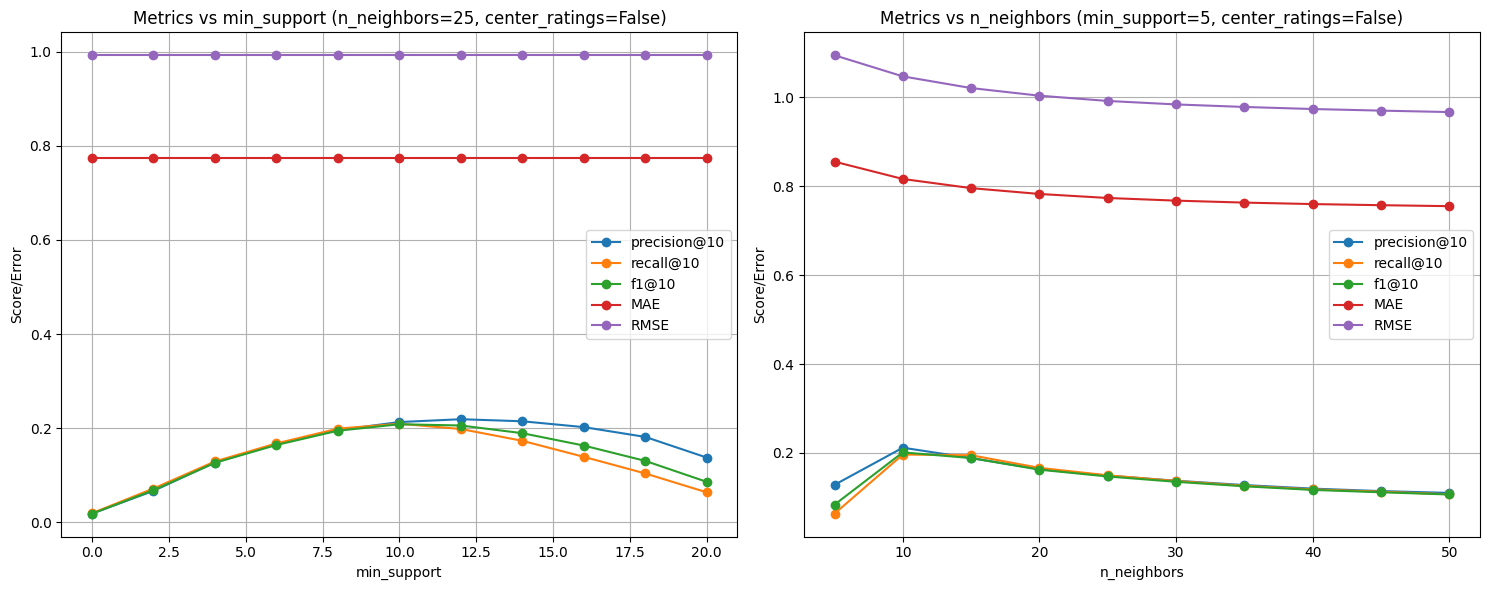

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15,6))
# 1. Vary min_support
min_support_values = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
fixed_params_1 = {'n_neighbors': 25, 'center_ratings': False}

results_min_support = {k: [] for k in ['precision@10', 'recall@10', 'f1@10', 'MAE', 'RMSE']}

for val in min_support_values:
    print(f"Testing min_support = {val}...")
    fold_metrics = {k: [] for k in results_min_support.keys()}
    
    for train_df, test_df in load_premade_splits("data"):
        model = UserKNNBasicRecommender(min_support=val, **fixed_params_1)
        model.fit(train_df)
        
        evaluator = RecommenderEvaluator(model, test_df, relevance_threshold=4, prec_rec_k=10)
        eval_results = evaluator.evaluation_report(
            k=10, 
            err_func=[mean_absolute_error, root_mean_squared_error]
        )
        
        fold_metrics['precision@10'].append(eval_results['precision@10'])
        fold_metrics['recall@10'].append(eval_results['recall@10'])
        fold_metrics['f1@10'].append(eval_results['f1@10'])
        fold_metrics['MAE'].append(eval_results['mean_absolute_error'])
        fold_metrics['RMSE'].append(eval_results['root_mean_squared_error'])
        
    for k in results_min_support.keys():
        results_min_support[k].append(np.mean(fold_metrics[k]))

for metric, values in results_min_support.items():
    ax[0].plot(min_support_values, values, marker='o', label=metric)
ax[0].set_title('Metrics vs min_support (n_neighbors=25, center_ratings=False)')
ax[0].set_xlabel('min_support')
ax[0].set_ylabel('Score/Error')
ax[0].legend()
ax[0].grid(True)

# 2. Vary n_neighbors
n_neighbors_values = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
fixed_params_2 = {'min_support': 5, 'center_ratings': False}

results_n_neighbors = {k: [] for k in ['precision@10', 'recall@10', 'f1@10', 'MAE', 'RMSE']}

for val in n_neighbors_values:
    print(f"Testing n_neighbors = {val}...")
    fold_metrics = {k: [] for k in results_n_neighbors.keys()}
    
    for train_df, test_df in load_premade_splits("data"):
        model = UserKNNBasicRecommender(n_neighbors=val, **fixed_params_2)
        model.fit(train_df)
        
        evaluator = RecommenderEvaluator(model, test_df, relevance_threshold=4, prec_rec_k=10)
        eval_results = evaluator.evaluation_report(
            k=10, 
            err_func=[mean_absolute_error, root_mean_squared_error]
        )
        
        fold_metrics['precision@10'].append(eval_results['precision@10'])
        fold_metrics['recall@10'].append(eval_results['recall@10'])
        fold_metrics['f1@10'].append(eval_results['f1@10'])
        fold_metrics['MAE'].append(eval_results['mean_absolute_error'])
        fold_metrics['RMSE'].append(eval_results['root_mean_squared_error'])
        
    for k in results_n_neighbors.keys():
        results_n_neighbors[k].append(np.mean(fold_metrics[k]))

for metric, values in results_n_neighbors.items():
    ax[1].plot(n_neighbors_values, values, marker='o', label=metric)
ax[1].set_title('Metrics vs n_neighbors (min_support=5, center_ratings=False)')
ax[1].set_xlabel('n_neighbors')
ax[1].set_ylabel('Score/Error')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [57]:
n_neighbors = 10
# ================== prediction & interpretation ==================
ratings_pred = model_knn.predict_ratings(test_df)
test_user_id = np.random.choice(test_df['user_id'].unique())
top_n_recs = model_knn.recommend_items(test_user_id, n=10)
print(f"Top-10 recommendations for user {test_user_id}: {top_n_recs}")

neighbors = model_knn.get_neighbors(test_user_id)
print(f"Users most similar to user {test_user_id}:")
for i, (neighbor, similarity) in enumerate(neighbors):
    print(f"    - User {neighbor} (similarity: {similarity:.3f})")
    if i >= n_neighbors:
        break

Top-10 recommendations for user 937: [(np.int64(100), np.float64(4.2845712643231755)), (np.int64(313), np.float64(4.163435305371341)), (np.int64(50), np.float64(4.123735686913477)), (np.int64(302), np.float64(4.097147896990123)), (np.int64(269), np.float64(4.081133935066799)), (np.int64(181), np.float64(3.708245409044369)), (np.int64(327), np.float64(3.674698616682336)), (np.int64(288), np.float64(3.5598464805051817)), (np.int64(286), np.float64(3.52908511837436)), (np.int64(258), np.float64(3.4800449171723358))]
Users most similar to user 937:
    - User 673 (similarity: 0.427)
    - User 278 (similarity: 0.390)
    - User 589 (similarity: 0.330)
    - User 376 (similarity: 0.293)
    - User 652 (similarity: 0.287)
    - User 667 (similarity: 0.280)
    - User 127 (similarity: 0.273)
    - User 19 (similarity: 0.264)
    - User 470 (similarity: 0.249)
    - User 853 (similarity: 0.246)
    - User 791 (similarity: 0.243)
